# Imports

In [1]:
# Plotting and display within the notebook
%matplotlib inline
import matplotlib.pyplot as plt
plt.rc("font",size=16)
from IPython.display import display

In [2]:
# Other general and scientific packages
import numpy as np
from scipy.optimize import minimize_scalar
from functools import partial
from collections import OrderedDict

In [3]:
# Symbolic equation manipulation
from sympy import *
init_printing()

# Define symbols

Coordinates

In [4]:
xyz=x,y,z=symbols("x,y,z",real=True)

Solution variables

In [5]:
w,beta,q=symbols("omega,beta,q")

Material parameters

In [6]:
p,c11,c12,c13,c33,c44=matparams=symbols("p,c_11,c_12,c_13,c_33,c_44")
Cmat=Matrix([
        [c11,c12,c13,  0,  0,0],
        [c12,c11,c13,  0,  0,0],
        [c13,c13,c33,  0,  0,0],
        [  0,  0,  0,c44,  0,0],
        [  0,  0,  0,  0,c44,0],
        [  0,  0,  0,  0,  0,(c11-c12)/2]])

A convenience dictionary which can replace material params with specific symbols for GaN or AlN

In [7]:
mpsubs={
    'GaN': OrderedDict(zip(matparams,symbols([mpi.name+("G" if "_" in mpi.name else "_G") for mpi in matparams]))),
    'AlN': OrderedDict(zip(matparams,symbols([mpi.name+("A" if "_" in mpi.name else "_A") for mpi in matparams])))
}
pG,c11G,c12G,c13G,c33G,c44G=mpsubs['GaN'].values()
pA,c11A,c12A,c13A,c33A,c44A=mpsubs['AlN'].values()

# Eg for GaN
mpsubs['GaN']

In [8]:
Cmats={
    None: Cmat,
    'GaN':Cmat.subs(mpsubs['GaN']),
    'AlN':Cmat.subs(mpsubs['AlN'])}

Dictionary for numerical substitutions

In [9]:
GPa=1e9
nm=1e-9
gpcm3=1e-3/1e-6
from scipy.constants import hbar, e
numerics={
    c11G: 390 *GPa,
    c12G: 145 *GPa,
    c13G: 106 *GPa,
    c33G: 398 *GPa,
    c44G: 105 *GPa,
    pG:  6.15 *gpcm3,
    
    c11A: 396 *GPa,
    c12A: 137 *GPa,
    c13A: 108 *GPa,
    c33A: 373 *GPa,
    c44A: 116 *GPa,
    pA:  3.26 *gpcm3,
}

In [10]:
meV=e/hbar*1e-3

Translate index pairs to single Voigt notation index

In [11]:
order=[(x,x),(y,y),(z,z),(y,z),(x,z),(x,y)]
print("Ordering:")
display(order)

def getind(i,j):
    pair=(i,j)
    return order.index(tuple(sorted(pair,key=lambda x:x.name)))

# Eg index for xy is 5
getind(x,y)

Ordering:


# Bulk modes

A single component of a mode will have the following form, with an $x$-wavevector $q$ and out-of-plane $\beta$:

In [12]:
mode=exp(I*beta*z)*exp(I*q*x)
mode

A bulk mode $u_i$ will have that form for each component with some coefficient $D_i$, where $i$ ranges $\{x,y,z\}$

In [13]:
Dxyz=symbols("D_x,D_y,D_z")
def u_blk(i,r=None):
    """ Components for a bulk mode with coefficients $D_i$.
    
    Args:
        i: one of the symbols x, y, or z
        r: (normally specifies a region, ignored for bulk)
    """
    return Dxyz[xyz.index(i)]*mode
u_blk(x),u_blk(y),u_blk(z)

The strain $\epsilon_{ij}$ is a symmetric derivative of the components

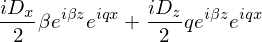

In [14]:
def S(u,i,j,r=None):
    """ Components of the strain tensor for the displacement function $u$.
    
    Args:
        u(k): a function returning the displacement component along $k$
        i,j: the indices (one of $\{x,y,z\}$) into the strain tensor
        r: region, passed to the displacement function
    """
    return Rational(1,2)*(diff(u(i,r),j)+diff(u(j,r),i))

# Example eps_xy
S(u_blk,x,z)

The stress component is related to the strain by the elastic tensor

In [15]:
def T(u,i,j,r=None,mat=None):
    """ Stress tensor component for displacement function $u$.
    
    Args:
        u(k): a function returning the displacement component along $k$
        i,j: the indices (one of $\{x,y,z\}$) into the stress tensor
        r: region, passed to the displacement function
    """
    
    # Get the six-component Voigt tuple
    Smat=Matrix([S(u,*o,r=r) for o in order])
    smat=diag(1,1,1,2,2,2)*Smat
    
    # Multiply by the Voigt form tensor
    return (Cmats[mat]*smat)[getind(i,j)]

# Example T_xx
T(u_blk,x,x)

The divergence of the stress tensor

In [16]:
def delT(u,i,r=None):
    """ Stress tensor divergence, component $i$.
    
    Args:
        u(k): a function returning the displacement component along $k$
        i: the indices (one of $\{x,y,z\}$) into the divergence of the stress tensor
        r: (region) passed to the displacement function
    """
    return simplify(sum(diff(T(u,i,j,r),j) for j in (x,y,z)))
delT(u_blk,z)

## Solving xz modes

Hooke's law matrix form (the matrix whose determinant should be zero)

\left[\begin{matrix}- \beta^{2} c_{44} - c_{11} q^{2} + \omega^{2} p & - \beta c_{13} q - \beta c_{44} q\\- \beta c_{13} q - \beta c_{44} q & - \beta^{2} c_{33} - c_{44} q^{2} + \omega^{2} p\end{matrix}\right]


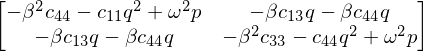

In [17]:
modematrix=Matrix([
    [expand(simplify((delT(u_blk,i)+p*w**2*u_blk(i))/exp(I*q*x)/exp(I*beta*z)))\
         .coeff(Dxyz[xyz.index(j)]) for j in [x,z]]\
    for i in [x,z]])
print(latex(modematrix))
modematrix

Determinant equation

In [18]:
print(latex(modematrix.det()))
modematrix.det()

- \left(- \beta c_{13} q - \beta c_{44} q\right)^{2} + \left(- \beta^{2} c_{33} - c_{44} q^{2} + \omega^{2} p\right) \left(- \beta^{2} c_{44} - c_{11} q^{2} + \omega^{2} p\right)


Coefficients of the determinant equation

In [19]:
B4=expand(modematrix.det()).coeff(beta,4)
B2=expand(modematrix.det()).coeff(beta,2)
B0=expand(modematrix.det()).coeff(beta,0)
print("B4:")
print(latex(B4))
display(B4)
print("\n\n")

print("B2:")
print(latex(B2))
display(B2)
print("\n\n")

print("B0:")
print(latex(factor(B0)))
display(factor(B0))

B4:
c_{33} c_{44}





B2:
c_{11} c_{33} q^{2} - c_{13}^{2} q^{2} - 2 c_{13} c_{44} q^{2} - c_{33} \omega^{2} p - c_{44} \omega^{2} p





B0:
\left(- c_{11} q^{2} + \omega^{2} p\right) \left(- c_{44} q^{2} + \omega^{2} p\right)


Dictionary to replace the symbols $\beta_{+1}$, $\beta_{-1}$ by the equations for the the two positive roots

In [20]:
Btwid=B2**2-4*B4*B0
betap,betam=symbols(r"{\beta_{+1}},{\beta_{-1}}")
betasubs={
    betap: sqrt(1/(2*B4)*(-B2+sqrt(Btwid))),
    betam: sqrt(1/(2*B4)*(-B2-sqrt(Btwid))),
}

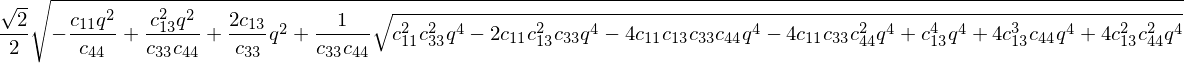

In [21]:
factor(expand(betasubs[betap].subs(w,0)))

Dictionary to replace symbols $\delta_{+1}$, $\delta_{-1}$ by the displacement ratios corresponding to the above two roots

In [22]:
deltap,deltam=symbols(r"{\delta_{+1}},{\delta_{-1}}")
deltasubs=dict(zip([deltap,deltam],
        [simplify((-modematrix[0,0]/modematrix[0,1]).subs(beta,betai)    .subs(betasubs))
         for betai in [betap,betam]]))

Dictionaries that do the above for material specific symbols (like $\beta_{Gp}$)

In [23]:
betaGp,betaGm,betaAp,betaAm=symbols(r"{\beta_{Gp}},{\beta_{Gm}},{\beta_{Ap}},{\beta_{Am}}")
deltaGp,deltaGm,deltaAp,deltaAm=symbols(r"{\delta_{Gp}},{\delta_{Gm}},{\delta_{Ap}},{\delta_{Am}}")
betasubsR={
    betaGp: betap.subs(betasubs).subs(mpsubs['GaN']),betaGm: betam.subs(betasubs).subs(mpsubs['GaN']),
    betaAp: betap.subs(betasubs).subs(mpsubs['AlN']),betaAm: betam.subs(betasubs).subs(mpsubs['AlN'])
}
deltasubsR={
    deltaGp: deltap.subs(deltasubs).subs(mpsubs['GaN']),deltaGm: deltam.subs(deltasubs).subs(mpsubs['GaN']),
    deltaAp: deltap.subs(deltasubs).subs(mpsubs['AlN']),deltaAm: deltam.subs(deltasubs).subs(mpsubs['AlN'])
}

Lamdified expressions for rapid evaluations of the above equations

In [24]:
l_betaAp=lambdify((q,w),betaAp.subs(betasubsR).subs(numerics))
l_betaAm=lambdify((q,w),betaAm.subs(betasubsR).subs(numerics))

In [25]:
l_deltaAp=lambdify((q,w),deltaAp.subs(deltasubsR).subs(numerics))
l_deltaAm=lambdify((q,w),deltaAm.subs(deltasubsR).subs(numerics))

In [26]:
l_betaGp=lambdify((q,w),betaGp.subs(betasubsR).subs(numerics))
l_betaGm=lambdify((q,w),betaGm.subs(betasubsR).subs(numerics))

In [27]:
l_deltaGp=lambdify((q,w),deltaGp.subs(deltasubsR).subs(numerics))
l_deltaGm=lambdify((q,w),deltaGm.subs(deltasubsR).subs(numerics))

### Showing $\beta$ is pure

In [28]:
P0=factor(expand(Btwid).coeff(q,0))/(p**2*w**4)
P2=simplify(expand(Btwid).coeff(q,2) /(p*w**2))
P4=factor(expand(Btwid).coeff(q,4))

print("P4:")
print(latex(P4))
display(P4)
print("\n\n")

print("P2:")
print(latex(P2))
display(P2)
print("\n\n")

print("P0:")
print(latex(P0))
display(P0)
print("\n\n")

P4:
\left(c_{11} c_{33} - c_{13}^{2}\right) \left(c_{11} c_{33} - c_{13}^{2} - 4 c_{13} c_{44} - 4 c_{44}^{2}\right)





P2:
- 2 c_{11} c_{33}^{2} + 2 c_{11} c_{33} c_{44} + 2 c_{13}^{2} c_{33} + 2 c_{13}^{2} c_{44} + 4 c_{13} c_{33} c_{44} + 4 c_{13} c_{44}^{2} + 4 c_{33} c_{44}^{2}





P0:
\left(c_{33} - c_{44}\right)^{2}


In [29]:
Ptwid=factor(P2**2-4*P4*P0)
print(latex(Ptwid))
Ptwid

- 16 c_{33} c_{44} \left(c_{13} + c_{44}\right)^{2} \left(c_{11} c_{33} - c_{11} c_{44} - c_{13}^{2} - 2 c_{13} c_{44} - c_{33} c_{44}\right)


The last factor is positive if the anisotropy factor is < 1, which is true for the III-Nitrides.  See Table 5 of [Qin et al](https://doi.org/10.3390/ma10121419)

## Velocities

In [30]:
vlA=float(sqrt(c11A/pA).subs(numerics))
vtA=float(sqrt(c44A/pA).subs(numerics))
vzA=float(sqrt(c33A/pA).subs(numerics))
vlG=float(sqrt(c11G/pG).subs(numerics))
vtG=float(sqrt(c44G/pG).subs(numerics))
vzG=float(sqrt(c33G/pG).subs(numerics))

vyA=float(sqrt((c11A-c12A)/2/pA).subs(numerics))
vyG=float(sqrt((c11G-c12G)/2/pG).subs(numerics))

In [31]:
vtG

## Check bulk modes

False
False


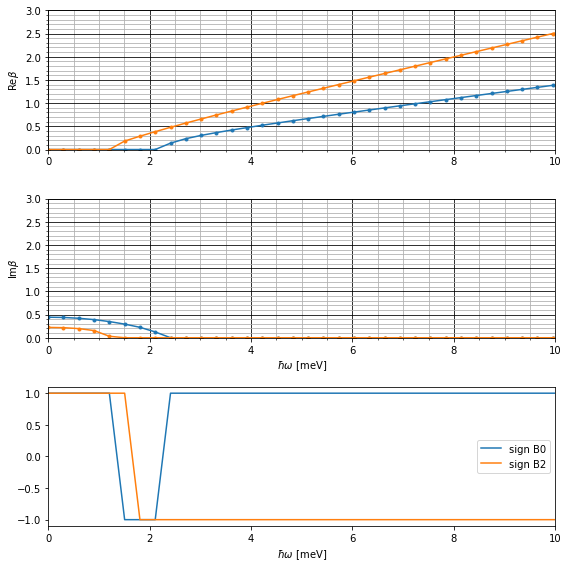

In [32]:
l_B0=lambdify((q,w),B0.subs(mpsubs['AlN']).subs(numerics))
l_B2=lambdify((q,w),B2.subs(mpsubs['AlN']).subs(numerics))
l_B4=lambdify((q,w),B4.subs(mpsubs['AlN']).subs(numerics))
def _():
    plt.figure(figsize=(8,8))
    axre=plt.subplot(311)
    axim=plt.subplot(312)
    axbi=plt.subplot(313)
    
    w=e/hbar*np.linspace(0,60e-3,num=200,dtype='complex')
    q=.31/nm
    #q=0.0001/nm
    lbam=l_betaAm(q,w)
    print(np.allclose(np.abs(np.angle(lbam)),np.pi/2))
    
    plt.sca(axre)
    plt.plot(hbar/e*w.real *1e3,lbam.real /1e9,'.-')
    plt.sca(axim)
    plt.plot(hbar/e*w.real *1e3,lbam.imag /1e9,'.-')
    
    lbap=l_betaAp(q,w)
    #print(lbap)
    print(np.allclose(np.abs(np.angle(lbap)),np.pi/2))
    
    plt.sca(axre)
    plt.plot(hbar/e*w.real *1e3,lbap.real /1e9,'.-')
    plt.sca(axim)
    plt.plot(hbar/e*w.real *1e3,lbap.imag /1e9,'.-')
    plt.sca(axbi)
    plt.plot(hbar/e*w.real *1e3,np.sign(l_B0(q,w.real)),label='sign B0')
    plt.plot(hbar/e*w.real *1e3,np.sign(l_B2(q,w.real)),label='sign B2')
    #plt.plot(hbar/e*w.real *1e3,np.sign(l_B4(q,w.real)),label='B4')
    
    
    plt.sca(axre)
    ymax=3
    xmax=10
    plt.ylim(0,ymax)
    plt.xlim(0,xmax)
    plt.ylabel(r"$\mathrm{Re}\beta$")
    plt.minorticks_on()
    plt.grid(True,which='both')
    plt.grid(color='k')
    plt.sca(axim)
    plt.ylim(0,ymax)
    plt.xlim(0,xmax)
    plt.xlabel(r"$\hbar \omega$ [meV]")
    plt.ylabel(r"$\mathrm{Im}\beta$")
    plt.minorticks_on()
    plt.grid(True,which='both')
    plt.grid(color='k')
    
    plt.sca(axbi)
    plt.ylim(-1.1,1.1)
    plt.xlim(0,xmax)
    plt.xlabel(r"$\hbar \omega$ [meV]")
    #plt.ylabel(r"$\mathrm{Im}\beta$")
    #plt.minorticks_on()
    #plt.grid(True,which='both')
    #plt.grid(color='k')
    plt.legend(loc='best')#,alpha=.5)
    
    plt.tight_layout()
_()

In [33]:
l_deltaAm(.1/nm,6*meV+0j),l_deltaAp(.1/nm,6*meV+0j)

((9.6767508604780215+0j), (-0.057329619956915913+0j))

52.4841371914


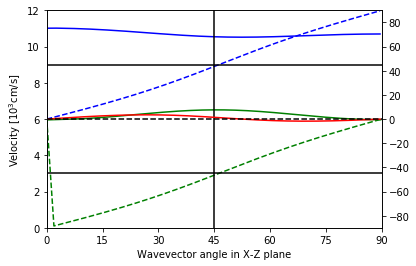

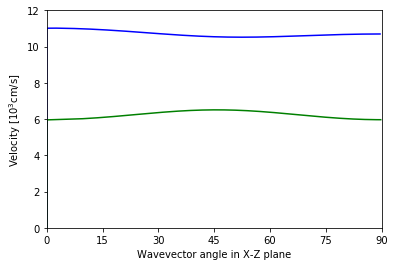

In [34]:
def _(deltas=False):
    plt.figure()
    ws=np.linspace(0,100*meV,100000)
    q=.1/nm
    
    bm=l_betaAm(q,ws+0j).real
    tm=np.arctan2(bm,q+0*ws)
    am=np.sqrt(bm**2+q**2)
    plt.plot(tm*180/np.pi,ws/am /1e3,'b')
    
    bp=l_betaAp(q,ws+0j).real
    tp=np.arctan2(bp,q+0*ws)
    ap=np.sqrt(bp**2+q**2)
    plt.plot(tp*180/np.pi,ws/ap /1e3,'g')
    
    plt.xlim(0,90)
    plt.xticks([0,15,30,45,60,75,90])
    plt.ylim(0,12)
    plt.ylabel("Velocity [10$^3$cm/s]")
    plt.xlabel("Wavevector angle in X-Z plane")
    
    if deltas:
        plt.twinx()
        plt.plot(tm*180/np.pi,180/np.pi*np.arctan2(np.real(l_deltaAm(q,ws+0j)),1),'b--')
        plt.plot(tp*180/np.pi,180/np.pi*np.arctan2(np.real(l_deltaAp(q,ws+0j)),1),'g--')
        plt.ylim(-90,90)
        plt.axvline(45,color='k')
        plt.axhline(45,color='k')
        plt.axhline(-45,color='k')
        dang=tm*180/np.pi-180/np.pi*np.arctan2(np.real(l_deltaAm(q,ws+0j)),1)
        plt.plot(tm*180/np.pi,dang,'r')
        plt.axhline(0,color='k',linestyle='--')
        mm=np.logical_and(tm*180/np.pi>30, tm*180/np.pi<70)
        print((tm*180/np.pi)[mm][np.argmin(np.abs(dang[mm]))])
    
    
_(deltas=True)
_(deltas=False)

/home/sam/miniconda3/lib/python3.6/site-packages/matplotlib/projections/polar.py:63: RuntimeWarning: invalid value encountered in less
  mask = r < 0


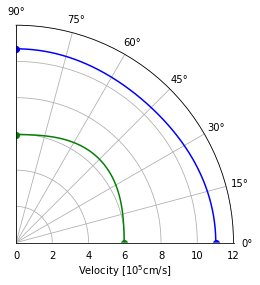

In [35]:
def _(vs=False):
    plt.figure()
    plt.subplot(polar=True)
    ws=np.logspace(-3,2,100000)*meV
    q=.1/nm
    
    bm=l_betaAm(q,ws+0j)
    bm[np.abs(bm.real)<np.abs(bm.imag)]=np.NaN
    bm=bm.real
    tm=np.arctan2(bm,q+0*ws)
    am=np.sqrt(bm**2+q**2)
    plt.plot(tm,ws/am/1e3,'b')
    
    bp=l_betaAp(q,ws+0j)
    bp[np.abs(bp.real)<np.abs(bp.imag)]=np.NaN
    bp=bp.real
    tp=np.arctan2(bp,q+0*ws)
    ap=np.sqrt(bp**2+q**2)
    plt.plot(tp,ws/ap/1e3,'g')
    
    plt.xlim(0,np.pi/2)
    plt.ylim(0,12)
    plt.xticks(np.r_[0,15,30,45,60,75,90]*np.pi/180)
    #plt.ylim(0,12)
    plt.xlabel("\nVelocity [10$^5$cm/s]")
    #plt.xlabel("Wavevector angle in X-Z plane")
    
    if vs:
        plt.plot(0,vtA/1e3,'go')
        plt.plot(0,vlA/1e3,'bo')
        plt.plot(np.pi/2,vtA/1e3,'go')
        plt.plot(np.pi/2,vzA/1e3,'bo')
    
_(vs=True)

## Bulk beta,q -> wm

In [36]:
D4=expand(modematrix.det()).coeff(w,4)
D2=expand(modematrix.det()).coeff(w,2)
D0=expand(modematrix.det()).coeff(w,0)
print("D4:")
print(latex(D4))
display(D4)
print("\n\n")

print("D2:")
print(latex(D2))
display(D2)
print("\n\n")

print("D0:")
print(latex(factor(D0)))
display(factor(D0))

D4:
p^{2}





D2:
- \beta^{2} c_{33} p - \beta^{2} c_{44} p - c_{11} p q^{2} - c_{44} p q^{2}





D0:
\beta^{4} c_{33} c_{44} + \beta^{2} c_{11} c_{33} q^{2} - \beta^{2} c_{13}^{2} q^{2} - 2 \beta^{2} c_{13} c_{44} q^{2} + c_{11} c_{44} q^{4}


In [ ]:
from scipy.optimize import curve_fit

NameError: name 'curve_fit' is not defined

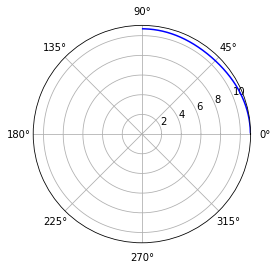

In [34]:
def _():
    plt.figure()
    plt.subplot(polar=True)
    ws_um=np.logspace(-3,2,100000)*meV
    q=.1/nm
    fm=lambda t,bow,bow2: vzA*(t/(np.pi/2))+vlA*(1-t/(np.pi/2))+bow*(1-t/(np.pi/2))*(t/(np.pi/2))+bow2*((1-t/(np.pi/2))*(t/(np.pi/2)))**2
    fp=lambda t,bow,bow2: vtA*(t/(np.pi/2))+vtA*(1-t/(np.pi/2))+bow*(1-t/(np.pi/2))*(t/(np.pi/2))+bow2*((1-t/(np.pi/2))*(t/(np.pi/2)))**2
    
    # 1
    bm=l_betaAm(q,ws_um+0j)
    mask=np.abs(bm.real)>np.abs(bm.imag)
    bm=bm[mask]
    ws=ws_um[mask]
    bm=bm.real
    tm=np.arctan2(bm,q+0*ws)
    am=np.sqrt(bm**2+q**2)
    plt.plot(tm,ws/am/1e3,'b')
    vm=ws/am
    bowm,bow2m=curve_fit(fm,
        tm,vm,p0=[0,0])[0]
    plt.plot(tm,fm(tm,bowm,bow2m)/1e3,'r--')
    
    #2
    bp=l_betaAp(q,ws_um+0j)
    mask=np.abs(bp.real)>np.abs(bp.imag)
    bp=bp[mask]
    ws=ws_um[mask]
    bp=bp.real
    tp=np.arctan2(bp,q+0*ws)
    ap=np.sqrt(bp**2+q**2)
    plt.plot(tp,ws/ap/1e3,'g')
    vp=ws/ap
    bowp,bow2p=curve_fit(fp,
        tp,vp,p0=[0,0])[0]
    plt.plot(tp,fp(tp,bowp,bow2p)/1e3,'r--')
    
    plt.xlim(0,np.pi/2)
    plt.ylim(0,12)
    plt.xticks(np.r_[0,15,30,45,60,75,90]*np.pi/180)
    #plt.ylim(0,12)
    plt.xlabel("\nVelocity [10$^5$cm/s]")
    #plt.xlabel("Wavevector angle in X-Z plane")
    
    plt.plot(0,vtA/1e3,'go')
    plt.plot(0,vlA/1e3,'bo')
    plt.plot(np.pi/2,vtA/1e3,'go')
    plt.plot(np.pi/2,vzA/1e3,'bo')

_()

GaN


NameError: name 'curve_fit' is not defined

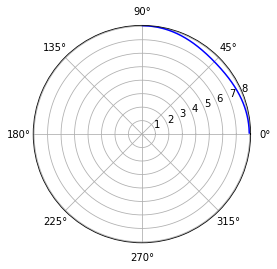

In [35]:
def _():
    print("GaN")
    plt.figure()
    plt.subplot(polar=True)
    ws_um=np.logspace(-3,2,100000)*meV
    q=.1/nm
    fm=lambda t,bow,bow2: vzG*(t/(np.pi/2))+vlG*(1-t/(np.pi/2))+bow*(1-t/(np.pi/2))*(t/(np.pi/2))+bow2*((1-t/(np.pi/2))*(t/(np.pi/2)))**2
    fp=lambda t,bow,bow2: vtG*(t/(np.pi/2))+vtG*(1-t/(np.pi/2))+bow*(1-t/(np.pi/2))*(t/(np.pi/2))+bow2*((1-t/(np.pi/2))*(t/(np.pi/2)))**2
    
    # 1
    bm=l_betaGm(q,ws_um+0j)
    mask=np.abs(bm.real)>np.abs(bm.imag)
    bm=bm[mask]
    ws=ws_um[mask]
    bm=bm.real
    tm=np.arctan2(bm,q+0*ws)
    am=np.sqrt(bm**2+q**2)
    plt.plot(tm,ws/am/1e3,'b')
    vm=ws/am
    bowm,bow2m=curve_fit(fm,
        tm,vm,p0=[0,0])[0]
    plt.plot(tm,fm(tm,bowm,bow2m)/1e3,'r--')
    print(vzG,vlG,bowm,bow2m)
    
    #2
    bp=l_betaGp(q,ws_um+0j)
    mask=np.abs(bp.real)>np.abs(bp.imag)
    bp=bp[mask]
    ws=ws_um[mask]
    bp=bp.real
    tp=np.arctan2(bp,q+0*ws)
    ap=np.sqrt(bp**2+q**2)
    plt.plot(tp,ws/ap/1e3,'g')
    vp=ws/ap
    bowp,bow2p=curve_fit(fp,
        tp,vp,p0=[0,0])[0]
    plt.plot(tp,fp(tp,bowp,bow2p)/1e3,'r--')
    print(vtG,vtG,bowp,bow2p)
    
    plt.xlim(0,np.pi/2)
    plt.ylim(0,12)
    plt.xticks(np.r_[0,15,30,45,60,75,90]*np.pi/180)
    #plt.ylim(0,12)
    plt.xlabel("\nVelocity [10$^5$cm/s]")
    #plt.xlabel("Wavevector angle in X-Z plane")
    
    plt.plot(0,vtG/1e3,'go')
    plt.plot(0,vlG/1e3,'bo')
    plt.plot(np.pi/2,vtG/1e3,'go')
    plt.plot(np.pi/2,vzG/1e3,'bo')

_()

In [36]:
vlG,vzG

NameError: name 'vlG' is not defined

In [422]:
vlA,vzA

AlN
10696.596557508863 11021.451476009719 -198.840332802 -4180.72140248
5965.133869905149 5965.133869905149 -336.999281361 9823.52681276


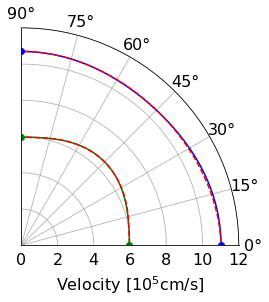

In [419]:
def _():
    print("AlN")
    plt.figure()
    plt.subplot(polar=True)
    ws_um=np.logspace(-3,2,100000)*meV
    q=.1/nm
    fm=lambda t,bow,bow2: vzA*(t/(np.pi/2))+vlA*(1-t/(np.pi/2))+bow*(1-t/(np.pi/2))*(t/(np.pi/2))+bow2*((1-t/(np.pi/2))*(t/(np.pi/2)))**2
    fp=lambda t,bow,bow2: vtA*(t/(np.pi/2))+vtA*(1-t/(np.pi/2))+bow*(1-t/(np.pi/2))*(t/(np.pi/2))+bow2*((1-t/(np.pi/2))*(t/(np.pi/2)))**2
    
    # 1
    bm=l_betaAm(q,ws_um+0j)
    mask=np.abs(bm.real)>np.abs(bm.imag)
    bm=bm[mask]
    ws=ws_um[mask]
    bm=bm.real
    tm=np.arctan2(bm,q+0*ws)
    am=np.sqrt(bm**2+q**2)
    plt.plot(tm,ws/am/1e3,'b')
    vm=ws/am
    bowm,bow2m=curve_fit(fm,
        tm,vm,p0=[0,0])[0]
    plt.plot(tm,fm(tm,bowm,bow2m)/1e3,'r--')
    print(vzA,vlA,bowm,bow2m)
    
    #2
    bp=l_betaAp(q,ws_um+0j)
    mask=np.abs(bp.real)>np.abs(bp.imag)
    bp=bp[mask]
    ws=ws_um[mask]
    bp=bp.real
    tp=np.arctan2(bp,q+0*ws)
    ap=np.sqrt(bp**2+q**2)
    plt.plot(tp,ws/ap/1e3,'g')
    vp=ws/ap
    bowp,bow2p=curve_fit(fp,
        tp,vp,p0=[0,0])[0]
    plt.plot(tp,fp(tp,bowp,bow2p)/1e3,'r--')
    print(vtA,vtA,bowp,bow2p)
    
    plt.xlim(0,np.pi/2)
    plt.ylim(0,12)
    plt.xticks(np.r_[0,15,30,45,60,75,90]*np.pi/180)
    #plt.ylim(0,12)
    plt.xlabel("\nVelocity [10$^5$cm/s]")
    #plt.xlabel("Wavevector angle in X-Z plane")
    
    plt.plot(0,vtA/1e3,'go')
    plt.plot(0,vlA/1e3,'bo')
    plt.plot(np.pi/2,vtA/1e3,'go')
    plt.plot(np.pi/2,vzA/1e3,'bo')

_()

# General problem

## Defining a problem

In [32]:
class XZ_Problem():
    def __init__(self,regions,bounds=['free','free'],zshift=0):
        self._symbols=[]
        self._regions=regions
        xexprs=[]
        zexprs=[]
        
        # For each region
        for ir,(r,m,t) in enumerate(regions):
            sir=str(ir)
            
            ## Which modes to allow
            
            # if -z direction is infinite, set -z directed modes to zero
            if ir==0 and t==oo:
                [Dpp,Dpm,Dmp,Dmm]=(0,0)+symbols(r"{D^{"+sir+"+}_{+1}},{D^{"+sir+"+}_{-1}}")
                self._symbols+=[Dmp,Dmm]
                
            # if +z direction is infinite, set +z directed modes to zero
            elif ir==len(regions)-1 and t==oo:
                [Dpp,Dpm,Dmp,Dmm]=symbols(r"{D^{"+sir+"+}_{+1}},{D^{"+sir+"+}_{-1}}")+(0,0)
                self._symbols+=[Dpp,Dpm]
                
            # if neither direction is infinite, all four modes
            else:
                [Dpp,Dpm,Dmp,Dmm]=symbols(r"{D^{"+sir+"+}_{+1}},{D^{"+sir+"+}_{-1}},{D^{"+sir+"-}_{+1}},{D^{"+sir+"-}_{-1}}")
                self._symbols+=[Dpp,Dpm,Dmp,Dmm]

            # dictionary to substitute in material-specific functions
            rsubs={
                'AlN':{betap: betaAp, betam: betaAm, deltap: deltaAp, deltam: deltaAm},
                'GaN':{betap: betaGp, betam: betaGm, deltap: deltaGp, deltam: deltaGm}}[m]
            
            # x and z ansatzes
            xexprs+=[(
                + Dpp*       mode.subs(beta, betap) + Dpm*       mode.subs(beta, betam)+\
                + Dmp*       mode.subs(beta,-betap) + Dmm*       mode.subs(beta,-betam))\
                .subs(rsubs)]
            zexprs+=[(
                + Dpp*deltap*mode.subs(beta, betap) + Dpm*deltam*mode.subs(beta, betam)+\
                - Dmp*deltap*mode.subs(beta,-betap) - Dmm*deltam*mode.subs(beta,-betam))\
                .subs(rsubs)]

        # Put it all together into one function
        def u(i,r=None):
            ir=[reg[0] for reg in regions].index(r)
            return {x:xexprs[ir],y:0,z:zexprs[ir]}[i]
        self._u=u
        
        ## Collect all boundary and interface equations
        equations=[]
        
        # Interface equations
        zint=zshift
        self._zints=[]
        for (r1,m1,t1),(r2,m2,t2) in zip(regions[:-1],regions[1:]):
            zint+=t1
            equations+=[(100*GPa/nm)*(u(i,r1)-u(i,r2)).subs(x,0).subs(z,zint) for i in [x,z]]
            equations+=[(T(u,i,z,r=r1,mat=m1)-T(u,i,z,r=r2,mat=m2)).subs(x,0).subs(z,zint) for i in [x,z]]
            self._zints+=[zint]
        
        # Boundaries
        for b,r,m,t,zb in [ [bounds[0]]+regions[0]+[zshift] , [bounds[1]]+regions[-1]+[zint+regions[-1][2]]]:
            if t!=oo:
                if b is 'free':
                    equations+=[T(u,i,z,r=r,mat=m).subs(x,0).subs(z,zb) for i in [x,z]]
                elif b is 'clamped':
                    equations+=[(100*GPa/nm)*u(i,r).subs(x,0).subs(z,zb) for i in [x,z]]
                
        # Matrixify
        self._mat=Matrix([[expand(row).coeff(v) for v in self._symbols] for row in equations])
        
        # Lambdify the matrix
        n=len(equations)
        l_m_=lambdify((q,w),self._mat.subs(betasubsR).subs(deltasubsR).subs(numerics)+Matrix([[1]*n]*n)*w/meV)
        self.lmat=lambda q,w: l_m_(q,w+0j)-np.ones((n,n)+np.asarray(w).shape)*w/meV
        
    def get_u_at(self,q,w):
        w=w+0j
        en,ev=np.linalg.eig(self.lmat(q,w))
        coeffs=dict(zip(self._symbols,ev[:,np.argmin(np.abs(en))]))
        bsubs={betaAm:l_betaAm(q,w),betaAp:l_betaAp(q,w),betaGm:l_betaGm(q,w),betaGp:l_betaGp(q,w)}
        dsubs={deltaAm:l_deltaAm(q,w),deltaAp:l_deltaAp(q,w),deltaGm:l_deltaGm(q,w),deltaGp:l_deltaGp(q,w)}        
        exprs=dict(zip([x,z],
                [[lambdify(z,self._u(i,r).subs(coeffs).subs(x,0).subs(dsubs).subs(bsubs)) for r,_,_ in self._regions]
                 for i in [x,z]]))
        #print(exprs)
        def u(i,z_):
            if len(self._zints):
                conds=[z_<zint for zint in self._zints]
                return np.piecewise(z_+0j,conds,exprs[i],)
            else:
                return exprs[i][0](z_+0j)
        return u

## Solving a problem

In [33]:
class XZ_Solution():
    def __init__(self,xzprob,qs,roots):
        self._qs=qs
        self._roots=roots
        self._xzprob=xzprob
        
    def nearestsoln(self,q,rootno=0,w=None, plot=False):
        i=np.argmin(np.abs(self._qs-q))
        q=qs[i]
        roots=self._roots[i]
        if w is not None:
            rootno=np.argmin(np.abs(roots-w))
        w=roots[rootno]
        u=self._xzprob.get_u_at(q,w)
        
        if plot:
            zn=np.linspace(*plot['xlim'],500)
            ux,uz=[u(i,zn) for i in [x,z]]
            plt.plot(zn/nm,ux.real,'b')
            plt.plot(zn/nm,ux.imag,'b--')
            plt.plot(zn/nm,uz.real,'g')
            plt.plot(zn/nm,uz.imag,'g--')
            plt.axvline(0,color='k',linewidth=.5)
            plt.axhline(0,color='k',linewidth=.5)
            plt.xlim(plot['xlim'][0]/nm,plot['xlim'][1]/nm)
            print("q [1/nm]: ",q*nm)
            print("w  [meV]: ",w/meV)
        
        return q,w,u
    
    

In [34]:
from scipy.interpolate import spline

In [338]:
def XZsolve(xzprob,q,wrange,dw,inspect=False,opts={}):
    qs=q
    roots=[]
    
    if 'sharpness' not in opts:
        opts['sharpness']=1e9/(1e-4*meV)
    
    if inspect:
        # Make plots
        plt.figure(figsize=(10,5))
        ax=plt.gca()
        
        # Make a color cycler to have a consistent color for each q
        def colorcycler():
            colors=['b','r','g','k','purple']
            i=0;
            while True:
                yield colors[i % len(colors)]
                i+=1
        cc=colorcycler()
        
    # Objective function
    objfunc=lambda w: np.abs(np.linalg.det(xzprob.lmat(q,w).T))
    
    if wrange[0]=="max":
        wmaxs=wrange[1]+qs*0
        wmins=qs*0
    if wrange[0]=="belowv":
        wmaxs=wrange[1]*qs
        wmins=qs*0
    if wrange[0]=="abovev":
        wmins=wrange[1]*qs
        if len(wrange)>2:
            wmaxs=wrange[2]+0*qs
        else:
            wmaxs=wrange[1]*(np.max(qs)+qs[1]-qs[0])+0*qs
    
    # For each q separately
    for q,wmin,wmax in zip(qs,wmins,wmaxs):
        print("Solving at q [1/nm]: ", q*nm)
        
        # Evaluate objective on evenly spaced energy grid
        w=np.linspace(wmin+dw/1e3,wmax-dw/1e3,int((wmax-wmin)/dw))
        dw=w[1]-w[0]
        #print("  dw: ",dw/meV, " meV")
        fgrid=objfunc(w)
        idx=np.isfinite(fgrid) & (fgrid!=0)
        poly=np.polyfit(w[idx],np.log(fgrid[idx]),deg=5)
        
        # Plot the gridded values
        if inspect:
            color=next(cc)
            plt.sca(ax)
            plt.plot(w/meV,fgrid,'.-')
            plt.plot(w/meV,np.exp(np.polyval(poly,w)),'--')
            plt.yscale('log')
        
        # Find indices of all approximate minima captured by the grid,
        # by noting where the sign of the difference changes
        rootsqi=np.arange(1,len(w)-1)[list(np.diff(np.sign(np.diff(fgrid)))==2)]
        rootsq=[np.NaN]*len(rootsqi)
        print("  ",len(rootsq)," potential roots to examine")
        topsq=w[np.arange(1,len(w)-1)[list(np.diff(np.sign(np.diff(fgrid)))==-2)]]
        
        # First, go through and refine the minima
        for i,iw in enumerate(rootsqi):
            bracket=w[iw-1:iw+2]
            ar=w[iw]
            #try:
            res=minimize_scalar(objfunc,bracket=bracket,method='brent')
            #except:
            #    print("Bracketed values: ",objfunc(bracket))
            #    # If minimize_scalar fails, show a zoom in on this point
            #    if inspect:
            #        plt.plot(ar/meV,objfunc(ar),'ro')
            #        plt.xlim((ar-10*dw)/meV,(ar+10*dw)/meV)
            #    raise
            wmin=res.x
            
            #assert (wmin>bracket[0]) and (wmin<bracket[-1])
            
            # Make sure the minimize routine actually lowers the value
            #print("brent imprv ",res.fun/objfunc(ar))
            if(res.fun>objfunc(ar)):
                print("Minimize scalar failed to do it's job...")
            else:
                rootsq[i]=wmin
                
        # Remove any "roots" for which minimize failed
        rootsq=[ar for ar in rootsq if not np.isnan(ar)]
                
        # Next, check for double roots, minima where the determinant doesn't change sign
        # Note: "sign" in the sense of [1,i,-1,-i]
        # We'll compare the "sign" at a point to the left and a point to the right in between
        # this minima and the nearest adjacent minima
        
        # Note that we're doing this double-root check *before* eliminating spurious minima
        # to make sure that the left and right points inside the "valid" range around the target
        # minima (that is, if we eliminated spurious solutions first, one of the comparison points)
        # might end up having one of those spurious spots in-between it and the target minima
        for i,ar in enumerate(rootsq):
            
            # Nearest minima to left/right, or w-boundary
            #left =np.min(w) if i==0             else rootsq[i-1][0]
            #right=np.max(w) if i==len(rootsq)-1 else rootsq[i+1]
            left =np.min(w) if i==0\
                else topsq[np.argmax(np.logical_and(topsq>rootsq[i-1][0], topsq<rootsq[i]))]
            right=np.max(w) if i==len(rootsq)-1\
                else topsq[np.argmax(np.logical_and(topsq>rootsq[i]     , topsq<rootsq[i+1]))]
            
            # Midway between that point and target minima
            left=ar+(left-ar)/2
            right=ar+(right-ar)/2
            
            # Sign to the left
            dl=np.linalg.det(xzprob.lmat(q,left+0j))
            dl=dl/np.abs(dl)
            
            # Sign to the right
            dr=np.linalg.det(xzprob.lmat(q,right+0j))
            dr=dr/np.abs(dr)
            
            # If the signs are the same, make it a double root, else single
            if np.isclose(dl,dr,atol=.1):
                rootsq[i]=[ar,ar]
            else:
                rootsq[i]=[ar]
                
        # Reflatten the list
        rootsq=sum(rootsq,[])
            
        
        # Next, elminate spurious solutions
        for i,ar in enumerate(rootsq):
            
            # magnitude of smallest eigenvalue
            #mineig=np.min(np.abs(np.linalg.eigvals(xzprob.lmat(q,ar).T)))
            
            # Make sure the smallest eigenvalue is actually "zero" enough
            #if mineig>1e2/nm**2:  #actually use 1e-2/nm**2:
            #    rootsq[i]=np.NaN
            
            #mineigl=np.min(np.abs(np.linalg.eigvals(xzprob.lmat(q,ar-dw).T)))
            #mineigr=np.min(np.abs(np.linalg.eigvals(xzprob.lmat(q,ar+dw).T)))
            #if mineig> max(mineigl,mineigr)/(opts['sharpness']*dw):
            #    rootsq[i]=np.NaN
            #    if inspect: print("Rejected {} because of sharpness".format(ar/meV))
            if objfunc(ar)==0: sharpness=np.inf
            else: sharpness=np.exp(np.polyval(poly,ar))/objfunc(ar)
            if sharpness<opts['sharpness']:
                rootsq[i]=np.NaN
                if inspect: print("Rejected {} because of sharpness {}".format(ar/meV,sharpness))
            
            # Make sure the two betas are not actually the same, in which case we don't
            # actually have four independent exponential modes like we thought, so the
            # solution is not a valid one... there may also be solutions of that form, 
            # but we'd have to solve for them separately and they seem too coincidental
            elif np.isclose(l_betaAm(q,ar+0j),l_betaAp(q,ar+0j),atol=1e-3/nm):
                rootsq[i]=np.NaN
                if inspect: print("Rejected {} because of betaA".format(ar/meV))
            elif np.isclose(l_betaGm(q,ar+0j),l_betaGp(q,ar+0j),atol=1e-3/nm):
                rootsq[i]=np.NaN
                if inspect: print("Rejected {} because of betaG".format(ar/meV))
            # Make sure no beta is zero, because then we don't have four modes
            elif np.abs(l_betaAm(q,ar+0j))<1e-3/nm:
                rootsq[i]=np.NaN
                if inspect: print("Rejected {} because of betaAm".format(ar/meV))
            elif np.abs(l_betaAp(q,ar+0j))<1e-3/nm:
                rootsq[i]=np.NaN
                if inspect: print("Rejected {} because of betaAp".format(ar/meV))
            elif np.abs(l_betaGm(q,ar+0j))<1e-3/nm:
                rootsq[i]=np.NaN
                if inspect: print("Rejected {} because of betaGm".format(ar/meV))
            elif np.abs(l_betaGp(q,ar+0j))<1e-3/nm: 
                rootsq[i]=np.NaN
                if inspect: print("Rejected {} because of betaGp".format(ar/meV))
            
            # Plot the ghost of a mode empty or the real thing filled in
            if inspect:
                if np.isnan(rootsq[i]):
                    plt.plot(ar/meV,sharpness,'o',mfc='w',mec=color)
                else:
                    if np.isfinite(sharpness):
                        plt.plot(ar/meV,sharpness,'o',mfc=color,mec=color)
                    plt.axvline(ar/meV,linestyle='--',color=color)
                    if inspect: print("Accepted {} with sharpness {}".format(ar/meV,sharpness))
                
        # Drop the invalid ones from consideration
        rootsq=[ar for ar in rootsq if not np.isnan(ar)]
        
        # Add these to a global list for all q's
        roots+=[rootsq]
    
    # Plot styles
    if inspect:
        plt.sca(ax)
        plt.yscale('log')
        plt.axvline(wmax/meV,color='k')
    
    # Rectangularize the roots collection
    
    minnumroots=np.min([len(r) for r in roots])
    maxnumroots=np.max([len(r) for r in roots])
    roots=np.array([(list(r)+[np.NaN]*(maxnumroots-minnumroots))[:maxnumroots] for r in roots])
    
    return XZ_Solution(xzprob,qs,roots)

# AlN slab

In [346]:
p_aslab=XZ_Problem([['slab','AlN',6*nm]],bounds=['free','free'],zshift=-3*nm)

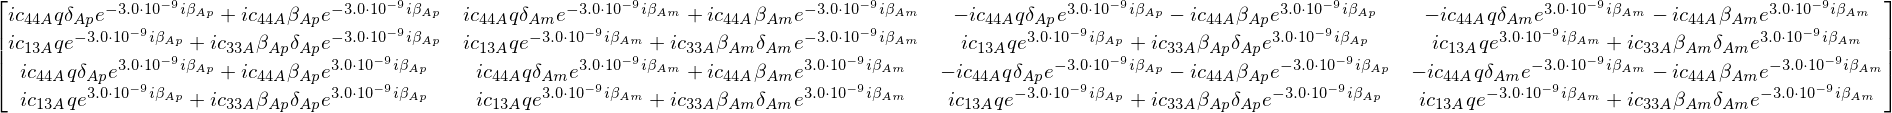

In [347]:
p_aslab._mat

In [348]:
# Run the solution
qs=np.linspace(.01e9,6.26e9,num=25)
s_aslab=XZsolve(p_aslab,
    q=qs,wrange=['max',40*meV],dw=1e-4*meV, inspect=False
)

Solving at q [1/nm]:  0.01
   32  potential roots to examine
Solving at q [1/nm]:  0.270416666667
   32  potential roots to examine
Solving at q [1/nm]:  0.530833333333
   32  potential roots to examine
Solving at q [1/nm]:  0.79125
   32  potential roots to examine
Solving at q [1/nm]:  1.05166666667
   32  potential roots to examine
Solving at q [1/nm]:  1.31208333333
   33  potential roots to examine
Solving at q [1/nm]:  1.5725
   32  potential roots to examine
Solving at q [1/nm]:  1.83291666667
   31  potential roots to examine
Solving at q [1/nm]:  2.09333333333
   31  potential roots to examine
Solving at q [1/nm]:  2.35375
   31  potential roots to examine
Solving at q [1/nm]:  2.61416666667
   30  potential roots to examine
Solving at q [1/nm]:  2.87458333333
   29  potential roots to examine
Solving at q [1/nm]:  3.135
   29  potential roots to examine
Solving at q [1/nm]:  3.39541666667
   29  potential roots to examine
Solving at q [1/nm]:  3.65583333333
   28  potential r

In [349]:
XZsolve(p_aslab,
    q=np.r_[1.33/nm],wmax=40*meV,dw=1e-4*meV, inspect=[0]
)
plt.sca(plt.gcf().axes[0])
plt.xlim(4,6)

TypeError: XZsolve() got an unexpected keyword argument 'wmax'

In [ ]:
XZsolve(p_aslab,
    q=np.r_[1.36050251256/nm],wmax=40*meV,dw=1e-4*meV, inspect=[0]
)
plt.sca(plt.gcf().axes[0])
plt.xlim(5.32,5.37)

In [ ]:
XZsolve(p_aslab,
    q=np.r_[4/nm],wmax=40*meV,dw=1e-4*meV, inspect=[0]
)
plt.sca(plt.gcf().axes[0])
plt.xlim(14.7,14.8)
#plt.xlim(5.32,5.37)

In [ ]:
# Plot it
qs,approxroots=s_aslab._qs,s_aslab._roots
plt.figure()
v1=float(sqrt(c44A/pA).subs(numerics))
#plt.fill_betweenx(v1*2*qs/meV,2*qs*nm,linewidth=.5,color='k',alpha=.2)
plt.plot(qs*nm,approxroots[:,:12]/meV,'.-')

#v2=float(sqrt(c44G/pG).subs(numerics))
#plt.plot(qs*nm,v2*qs/meV,linewidth=.5,color='k')

plt.xlim(0,qs[-1]*nm)
plt.ylim(0,37)
#plt.ylim(-1,37)
#plt.xlim(0,6.26)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
#plt.yticks([0,5,10,15,20,25,30,35])
plt.grid(True)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [1/nm]")

#plt.xlim(1,1.4)
#plt.ylim(0,10)

In [ ]:
s_aslab._roots[43]/meV

In [ ]:
s_aslab.

In [ ]:
s_aslab.nearestsoln(1.37/nm,rootno=1,plot={'xlim':[-3*nm,3*nm]})

# Sandwich

In [245]:
p_san=XZ_Problem([['top','AlN',1*nm],['cen','GaN',4*nm],['bot','AlN',1*nm]],bounds=['free','free'],zshift=-3*nm)

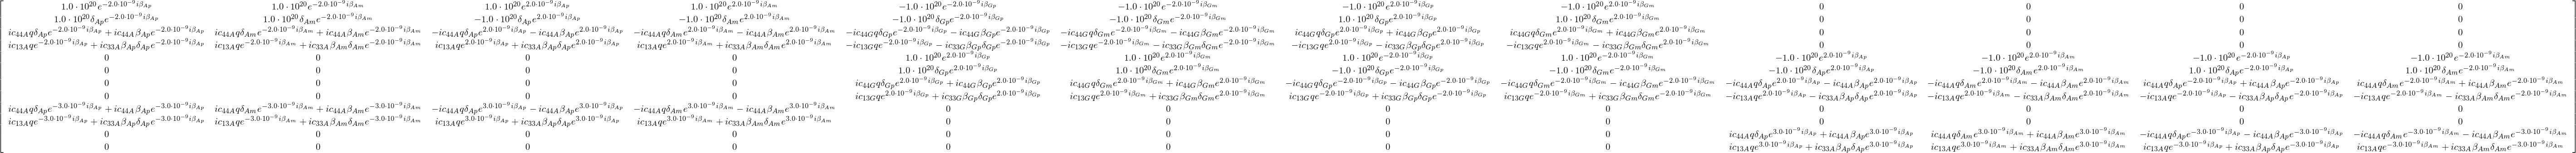

In [246]:
p_san._mat

Solving at q [1/nm]:  3.6725
   27  potential roots to examine
Rejected 9.905927676083495 because of sharpness
Rejected 9.905927676083495 because of sharpness
Accepted 10.289853804611642
Accepted 11.112937530131832
Accepted 12.212063414687002
Accepted 13.241921108354925
Accepted 14.114323342015132
Accepted 15.115380162536125
Accepted 16.349598268447895
Accepted 17.642393330788394
Accepted 18.892833436293618
Accepted 19.249626897894377
Accepted 19.491576773553263
Accepted 20.17326789643363
Accepted 20.300019106232664
Accepted 21.536059691281718
Accepted 21.64743391719698
Accepted 22.956257070314983
Accepted 23.36510299126906
Accepted 24.343224231249245
Accepted 24.966012378440666
Accepted 25.78956412919048
Accepted 26.0350935210073
Accepted 26.641971446669242
Accepted 27.2942136542868
Accepted 27.50579821266991
Accepted 29.013262842873957
Accepted 29.085807158719877


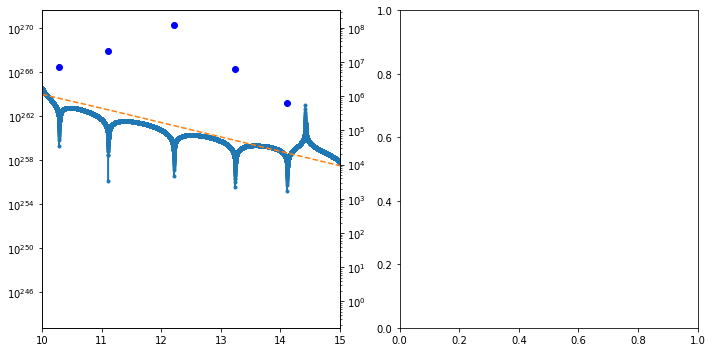

In [343]:
XZsolve(p_san,
    q=np.r_[3.6725/nm],wrange=['max',30*meV],dw=1e-4*meV, inspect=True,opts={'sharpness':1e4/meV}
)
plt.sca(plt.gcf().axes[0])
plt.xlim(10,15)

Solving at q [1/nm]:  3.41375
   29  potential roots to examine
Rejected 9.201020596607945 because of sharpness
Rejected 9.201020596607945 because of sharpness
Accepted 9.589284181183208
Accepted 10.41146512999591
Accepted 11.480052807044682
Accepted 12.477296726466053
Accepted 13.402927995742097
Accepted 14.494835729042448
Accepted 15.753121177932462
Accepted 17.014117219565545
Accepted 17.893373084046665
Accepted 18.16848623855527
Accepted 18.196755494009953
Accepted 19.07723562029284
Accepted 19.45105261617334
Accepted 20.52571696750114
Accepted 20.85957093068876
Accepted 22.246406433362246
Accepted 22.317164565186722
Accepted 23.675879562563235
Accepted 23.690117105723097
Accepted 24.764882484509283
Accepted 24.79121196063045
Accepted 25.109647217731435
Accepted 26.283712792169414
Accepted 26.808685394338486
Accepted 28.135159095666065
Accepted 28.38411104102461
Accepted 29.823871494876524
Accepted 29.90301591319652


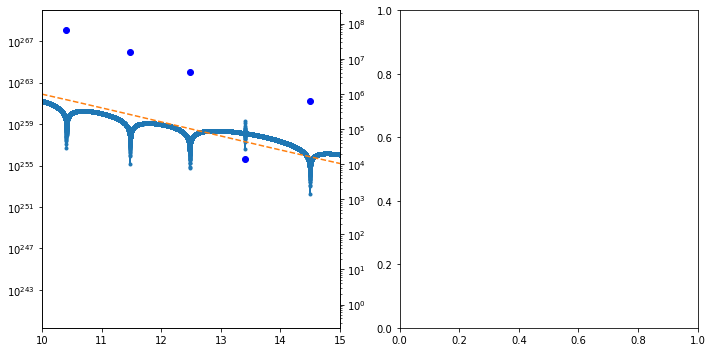

In [342]:
XZsolve(p_san,
    q=np.r_[3.41375/nm],wrange=['max',30*meV],dw=1e-4*meV, inspect=True,opts={'sharpness':1e4/meV}
)
plt.sca(plt.gcf().axes[0])
plt.xlim(10,15)

In [340]:
# Run the solution
qs=np.linspace(.05e9,6.26e9,num=25)
s_san=XZsolve(p_san,
    q=qs,wrange=['max',30*meV],dw=1e-4*meV, inspect=False,opts={'sharpness':1e4/meV}
)

Solving at q [1/nm]:  0.05
   32  potential roots to examine
Solving at q [1/nm]:  0.30875
   32  potential roots to examine
Solving at q [1/nm]:  0.5675
   32  potential roots to examine
Solving at q [1/nm]:  0.82625
   32  potential roots to examine
Solving at q [1/nm]:  1.085
   32  potential roots to examine
Solving at q [1/nm]:  1.34375
   32  potential roots to examine
Solving at q [1/nm]:  1.6025
   33  potential roots to examine
Solving at q [1/nm]:  1.86125
   31  potential roots to examine
Solving at q [1/nm]:  2.12
   31  potential roots to examine
Solving at q [1/nm]:  2.37875
   31  potential roots to examine
Solving at q [1/nm]:  2.6375
   31  potential roots to examine
Solving at q [1/nm]:  2.89625
   29  potential roots to examine
Solving at q [1/nm]:  3.155
   29  potential roots to examine
Solving at q [1/nm]:  3.41375
   29  potential roots to examine
Solving at q [1/nm]:  3.6725
   27  potential roots to examine
Solving at q [1/nm]:  3.93125
   27  potential roots t

Text(0.5,0,'In-plane wavevector [1/nm]')

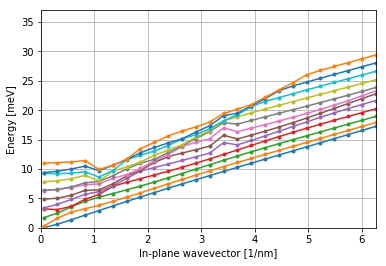

In [344]:
# Plot it
qs,approxroots=s_san._qs,s_san._roots
plt.figure()
v1=float(sqrt(c44A/pA).subs(numerics))
#plt.fill_betweenx(v1*2*qs/meV,2*qs*nm,linewidth=.5,color='k',alpha=.2)
plt.plot(qs*nm,approxroots[:,:12]/meV,'.-')

#v2=float(sqrt(c44G/pG).subs(numerics))
#plt.plot(qs*nm,v2*qs/meV,linewidth=.5,color='k')

plt.xlim(0,qs[-1]*nm)
plt.ylim(0,37)
#plt.ylim(-1,37)
#plt.xlim(0,6.26)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
#plt.yticks([0,5,10,15,20,25,30,35])
plt.grid(True)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [1/nm]")

#plt.xlim(1,1.4)
#plt.ylim(0,10)

# continuum pFET

In [203]:
p_pfetc=XZ_Problem([['well','GaN',10*nm],['buff','AlN',35*nm]],bounds=['free','clamped'],zshift=-10*nm)

Solving at q [1/nm]:  1.12118644068
   11  potential roots to examine
Accepted 4.4438396989452436 with sharpness inf
Accepted 4.542099083007319 with sharpness inf
Accepted 4.653989123324182 with sharpness 20702.69050507067
Accepted 4.833138030537285 with sharpness inf
Accepted 5.059613533080661 with sharpness 56466.755303515
Accepted 5.258615051671811 with sharpness 21483.144002106532
Accepted 5.468315583310325 with sharpness 70024.86514940867
Accepted 5.7038728660927935 with sharpness 143157.09433586893
Accepted 5.8554084675345885 with sharpness 4345604.190982505
Rejected 5.876765269452523 because of betaGm
Accepted 5.991851733402091 with sharpness 103827.56206121734


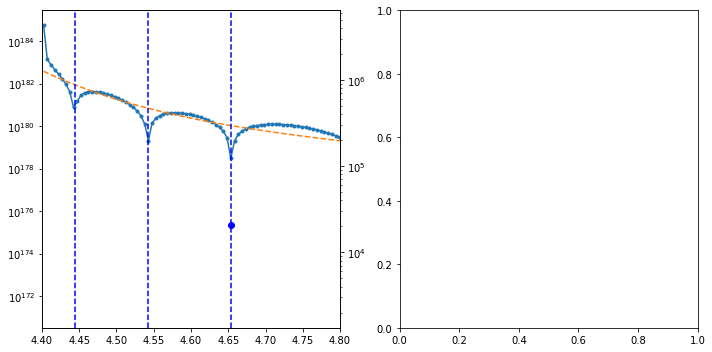

In [134]:
with np.errstate(divide='raise'):
    qs=np.r_[1.12118644068]/nm
    XZsolve(p_pfetc,
        q=qs,wrange=['abovev',vtA,6*meV],dw=5e-3*meV, inspect=[0],
    )
#plt.xlim(4.45,4.65)
plt.xlim(4.4,4.8)

In [153]:
l_betaAm(1.27271186441/nm,5.11*meV+0j)*nm,l_betaAp(1.27271186441/nm,5.11*meV+0j)*nm,\
l_betaGm(1.27271186441/nm,5.11*meV+0j)*nm,l_betaGp(1.27271186441/nm,5.11*meV+0j)*nm

(1.4067740089182506j,
 (0.21125012586437486+0j),
 1.1202677366607912j,
 (0.99921703839294163+0j))

Solving at q [1/nm]:  1.4
   52  potential roots to examine
Accepted 5.530147993648633 with sharpness 8.066001463512926
Accepted 5.530147993648633 with sharpness 8.066001463512926
Accepted 5.538163720829517 with sharpness inf
Accepted 5.538163720829517 with sharpness inf
Rejected 5.548823236331688 because of sharpness 1.9895601327418637
Rejected 5.548823236331688 because of sharpness 1.9895601327418637
Rejected 5.566566900670443 because of sharpness 0.7404075100102201
Rejected 5.566566900670443 because of sharpness 0.7404075100102201
Rejected 5.57147112890358 because of sharpness 0.7316331331761086
Rejected 5.57147112890358 because of sharpness 0.7316331331761086
Rejected 5.578436664664347 because of sharpness 0.6721971561492129
Rejected 5.578436664664347 because of sharpness 0.6721971561492129
Rejected 5.5889414898776275 because of sharpness 0.6041070661858534
Rejected 5.5889414898776275 because of sharpness 0.6041070661858534
Rejected 5.602938657257539 because of sharpness 0.71528059

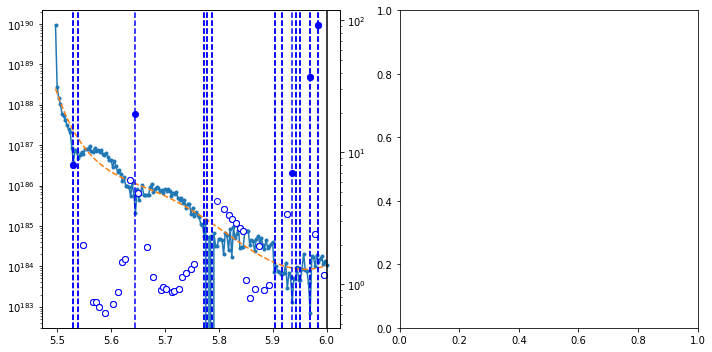

In [188]:
with np.errstate(divide='raise'):
    qs=np.r_[1.4]/nm
    XZsolve(p_pfetc,
        q=qs,wrange=['abovev',vtA,6*meV],dw=3e-3*meV, inspect=[0],opts={'sharpness':1e9/(1e-4*meV)}
    )
#plt.xlim(4.45,4.65)
#plt.xlim(4.4,4.8)
#plt.xlim(5.1,5.125)

q [1/nm]:  1.14644067797
w  [meV]:  4.91729532836


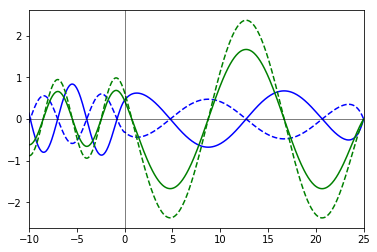

In [106]:
s_pfetc.nearestsoln(.05/nm,plot={'xlim':[-10*nm,25*nm]},rootno=3);

In [204]:
# Run the solution
with np.errstate(divide='raise'):
    qs=np.linspace(.01e9,1.4e9,num=60)
    s_pfetc=XZsolve(p_pfetc,
        q=qs,wrange=['abovev',vtA,6*meV],dw=3e-3*meV, inspect=False, opts={'sharpness':1e9/(1e-4*meV)}
    )

Solving at q [1/nm]:  0.01
   39  potential roots to examine
Solving at q [1/nm]:  0.0335593220339
   39  potential roots to examine
Solving at q [1/nm]:  0.0571186440678
   39  potential roots to examine
Solving at q [1/nm]:  0.0806779661017
   38  potential roots to examine
Solving at q [1/nm]:  0.104237288136
   38  potential roots to examine
Solving at q [1/nm]:  0.127796610169
   38  potential roots to examine
Solving at q [1/nm]:  0.151355932203
   38  potential roots to examine
Solving at q [1/nm]:  0.174915254237
   37  potential roots to examine
Solving at q [1/nm]:  0.198474576271
   37  potential roots to examine
Solving at q [1/nm]:  0.222033898305
   37  potential roots to examine
Solving at q [1/nm]:  0.245593220339
   37  potential roots to examine
Solving at q [1/nm]:  0.269152542373
   36  potential roots to examine
Solving at q [1/nm]:  0.292711864407
   37  potential roots to examine
Solving at q [1/nm]:  0.316271186441
   36  potential roots to examine
Solving at q 

Text(0.5,0,'In-plane wavevector [1/nm]')

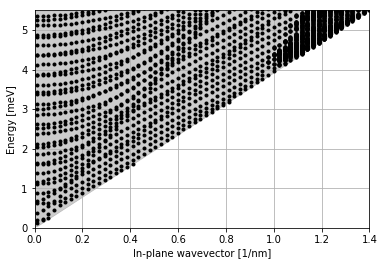

In [205]:
# Plot it
qs,approxroots=s_pfetc._qs,s_pfetc._roots
plt.figure()
v1=float(sqrt(c44A/pA).subs(numerics))
plt.fill_betweenx(v1*qs/meV,qs*nm,linewidth=.5,color='k',alpha=.2)
plt.plot(qs*nm,approxroots/meV,'.k')

#v2=float(sqrt(c44G/pG).subs(numerics))
#plt.plot(qs*nm,v2*qs/meV,linewidth=.5,color='k')

plt.xlim(0,qs[-1]*nm)
plt.ylim(0,v1*qs[-1]/meV)
#plt.ylim(-1,37)
#plt.xlim(0,6.26)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
#plt.yticks([0,5,10,15,20,25,30,35])
plt.grid(True)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [1/nm]")

#plt.ylim(4.4,4.8)
#plt.xlim(1,1.2)

Text(0.5,0,'In-plane wavevector [1/nm]')

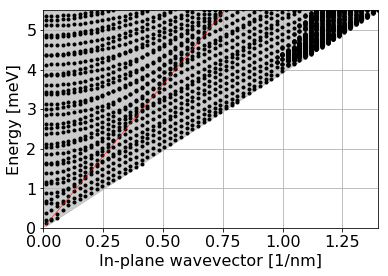

In [327]:
# Plot it
qs,approxroots=s_pfetc._qs,s_pfetc._roots
plt.figure()
v1=float(sqrt(c44A/pA).subs(numerics))
plt.fill_betweenx(v1*qs/meV,qs*nm,linewidth=.5,color='k',alpha=.2)
plt.plot(qs*nm,approxroots/meV,'.k')

#v2=float(sqrt(c44G/pG).subs(numerics))
plt.plot(qs*nm,vlA*qs/meV,linewidth=.5,color='r')


plt.xlim(0,qs[-1]*nm)
plt.ylim(0,v1*qs[-1]/meV)
#plt.ylim(-1,37)
#plt.xlim(0,6.26)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
#plt.yticks([0,5,10,15,20,25,30,35])
plt.grid(True)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [1/nm]")

#plt.ylim(4.4,4.8)
#plt.xlim(1,1.2)

# thick pFET

In [339]:
p_pfett=XZ_Problem([['well','GaN',10*nm],['buff','AlN',oo]],bounds=['free','clamped'],zshift=-10*nm)

Solving at q [1/nm]:  0.4
   2  potential roots to examine
Accepted 1.0692827967290386 with sharpness 7505301.963421956
Accepted 1.570088312702142 with sharpness 343045.2034655994


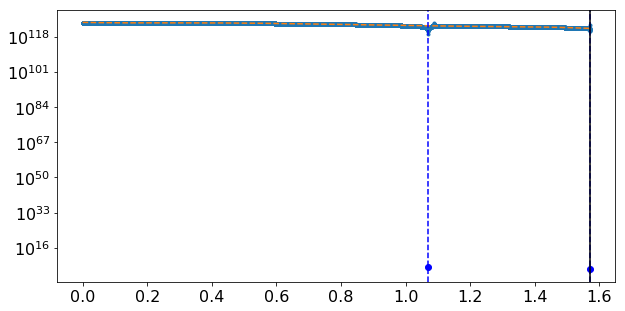

In [367]:
# Run the solution
qs=np.r_[0.4]/nm
s_pfett=XZsolve(p_pfett,
    q=qs,wrange=['belowv',vtA],dw=1e-4*meV, inspect=[0]
)

q [1/nm]:  0.4
w  [meV]:  1.5700883127


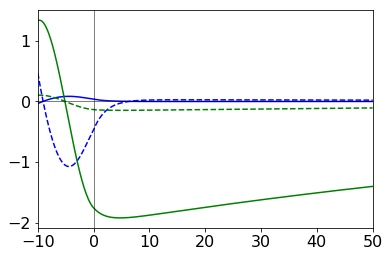

In [369]:
s_pfett.nearestsoln(.01/nm,rootno=1,plot={'xlim':[-10*nm,50*nm]});

In [201]:
# Run the solution
qs=np.linspace(.01e9,1.4e9,num=60)
s_pfett=XZsolve(p_pfett,
    q=qs,wrange=['belowv',vtA],dw=1e-4*meV, inspect=False
)

Solving at q [1/nm]:  0.01
   2  potential roots to examine
Solving at q [1/nm]:  0.0335593220339
   2  potential roots to examine
Solving at q [1/nm]:  0.0571186440678
   2  potential roots to examine
Solving at q [1/nm]:  0.0806779661017
   2  potential roots to examine
Solving at q [1/nm]:  0.104237288136
   2  potential roots to examine
Solving at q [1/nm]:  0.127796610169
   2  potential roots to examine
Solving at q [1/nm]:  0.151355932203
   2  potential roots to examine
Solving at q [1/nm]:  0.174915254237
   2  potential roots to examine
Solving at q [1/nm]:  0.198474576271
   2  potential roots to examine
Solving at q [1/nm]:  0.222033898305
   2  potential roots to examine
Solving at q [1/nm]:  0.245593220339
   3  potential roots to examine
Solving at q [1/nm]:  0.269152542373
   3  potential roots to examine
Solving at q [1/nm]:  0.292711864407
   3  potential roots to examine
Solving at q [1/nm]:  0.316271186441
   3  potential roots to examine
Solving at q [1/nm]:  0.339

Text(0.5,0,'In-plane wavevector [1/nm]')

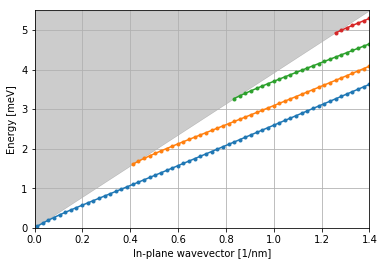

In [202]:
# Plot it
qs,approxroots=s_pfett._qs,s_pfett._roots
plt.figure()
v1=float(sqrt(c44A/pA).subs(numerics))
plt.fill_betweenx(v1*qs/meV,qs*nm,linewidth=.5,color='k',alpha=.2)
plt.plot(qs*nm,approxroots/meV,'.-')

#v2=float(sqrt(c44G/pG).subs(numerics))
#plt.plot(qs*nm,v2*qs/meV,linewidth=.5,color='k')

plt.xlim(0,qs[-1]*nm)
plt.ylim(0,v1*qs[-1]/meV)
#plt.ylim(-1,37)
#plt.xlim(0,6.26)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
#plt.yticks([0,5,10,15,20,25,30,35])
plt.grid(True)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [1/nm]")

In [378]:
np.sqrt(vtG*(2*np.pi/(2*10))**2/(vtA-vtG))

In [376]:
np.sqrt(vtG*(2*np.pi/(2*10/2))**2/(vtA-vtG))

In [375]:
np.sqrt(vtG*(2*np.pi/(2*10/3))**2/(vtA-vtG))

# Comp

In [ ]:

qs,approxroots=s_aslab._qs,s_aslab._roots

In [221]:
from contextlib import contextmanager

In [237]:
@contextmanager
def plot_over(img,pltbnd,pltsclx,pltscly,helpalign=False):
    """ Sets up a figure using an image file as the substrate on which to align a plot
    
    Args:
        img - filename from which to pull the substrate figure
        pltbnd - 4-tuple: coordinates of the left, bottom, top, and right of the axes in the substrate figure
            in the coordinate system of the output figure
            (use helpalign=True to mark these locations with blue dash)
        pltsclx - 4-tuple: the x-coordinate of one point in system of output figure, and corresponding
            data x coordinate, the x-coordinate of another point in system of output figure, and
            corresponding data x coordinate.  (use helpalign=True to mark these locations with red dash) 
        pltscly - 4-tuple: the y-coordinate of one point in system of output figure, and corresponding
            data y coordinate, the y-coordinate of another point in system of output figure, and
            corresponding data y coordinate.  (use helpalign=True to mark these locations with red dash)   
    """
    
    xbl,ybl,xtr,ytr=pltbnd
    x1,xn1,x2,xn2=pltsclx
    y1,yn1,y2,yn2=pltscly
    img=plt.imread(img)
    plt.figure(figsize=(10,10))
    plt.imshow(img)
    
    if helpalign:
        plt.axhline(ybl,linestyle='--',color='b')
        plt.axhline(ytr,linestyle='--',color='b')
        plt.axvline(xbl,linestyle='--',color='b')
        plt.axvline(xtr,linestyle='--',color='b')
        
        plt.axhline(y1,linestyle='--',color='r')
        plt.axhline(y2,linestyle='--',color='r')
        plt.axvline(x1,linestyle='--',color='r')
        plt.axvline(x2,linestyle='--',color='r')
    else:
        plt.axis('off')
        
    
    # This is crucial to ensure matplotlib finalizes axis positions before we take them
    plt.draw()
    # Conversion from data coordinates to figure coordinates
    data2fig=lambda x,y: \
        plt.gcf().transFigure.inverted().transform(plt.gca().transData.transform([x,y])) 
    plt.axes(np.concatenate([data2fig(xbl,ybl),(data2fig(xtr,ytr)-data2fig(xbl,ybl))]),facecolor='None')
    
    xnbl=xn1+(xbl-x1)*(xn2-xn1)/(x2-x1)
    xntr=xn1+(xtr-x1)*(xn2-xn1)/(x2-x1)
    ynbl=yn1+(ybl-y1)*(yn2-yn1)/(y2-y1)
    yntr=yn1+(ytr-y1)*(yn2-yn1)/(y2-y1)
    plt.gca().axis('off')
    
    yield
    plt.xlim(xnbl,xntr)
    plt.ylim(ynbl,yntr)

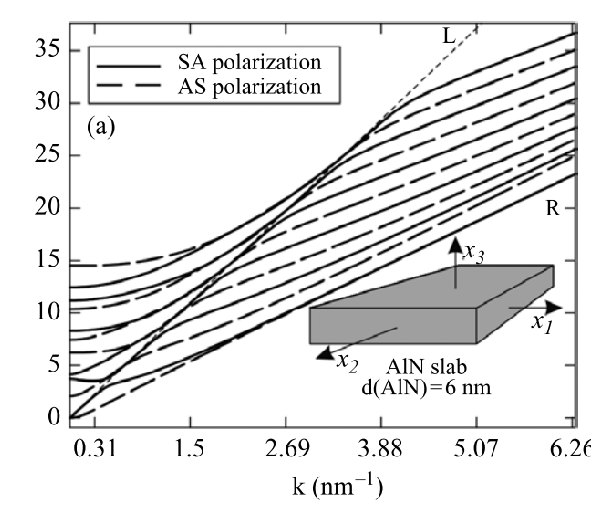

In [238]:
with plot_over("EP_Fig4a.png",[40,456,596,13],[67,.31,592,6.26],[446,0,43.35,35],helpalign=False):
    pass

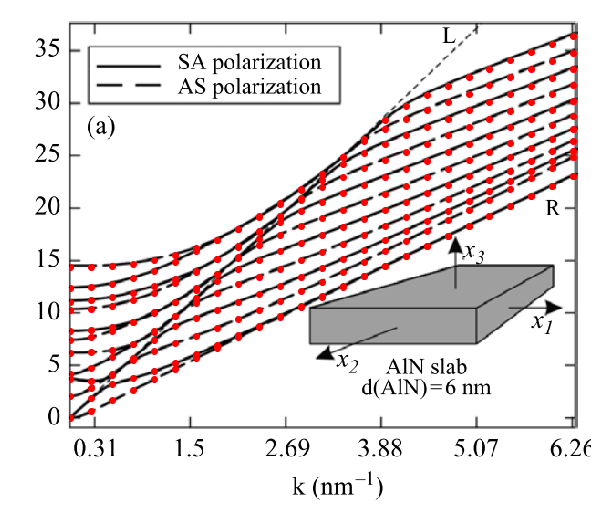

In [318]:
with plot_over("EP_Fig4a.png",[40,456,596,13],[67,.31,592,6.26],[446,0,43.35,35],helpalign=False):

    # Plot it
    qs,approxroots=s_aslab._qs,s_aslab._roots
    plt.plot(qs*nm,approxroots[:,:12]/meV,'ro');


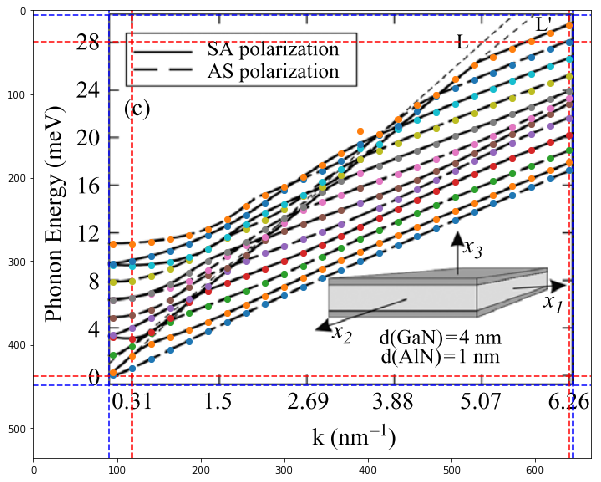

In [336]:
with plot_over("EP_Fig4c.png",[90,448,646,6],[118,.31,641,6.26],[437,0,38,28],helpalign=True):

    # Plot it
    qs,approxroots=s_san._qs,s_san._roots
    plt.plot(qs*nm,approxroots[:,:12]/meV,'o');
